In [1]:
import skimage.io as io
import os
import matplotlib.pyplot as plt
import numpy as np
import skimage.exposure as exposure
import skimage.color as color
import skimage.util as util

In [2]:
'''
Check if photo was taken during the dark hours in the growth chamber
filename: the file name of the image you want to check
lightsoff: the time that the lights turn off in the chamber
lightson: the time that the lights turn on in the chamber
returns True if image is from night time in the chamber, False if it is not
'''
def is_nightime(filename, lightsoff = 0, lightson = 20300):
    #extract time as int
    name_split = filename.split('_')
    time = int(name_split[-2])
    # remove if after lights out and before lights on
    if time > lightsoff and time < lightson:
        return True
    else:
        return False
'''
Remove the yellow tone when phone has incorrect white balance
Can only use if reference image is taken with same camera position otherwise output will be corrupted
yellow_images: a list of images with too-yellow white balance
ref_image: a reference image with the correct white balance, must be from yellow_images
returns a list of images corrected to the reference image white balance
'''
def remove_yellow_tone(yellow_images, ref_image):
    unyellowed = []
    for img in yellow_images:
        matched_image = exposure.match_histograms(img, ref_image, channel_axis=-1)
        unyellowed.append(matched_image)
    return unyellowed

# Example Utilization

In [4]:
# read in the leaves
leaves = []
directory = '../../captured/Avocet+Yr15-control/'
files = sorted(os.listdir(directory))
if '.ipynb_checkpoints' in files:
    files.remove('.ipynb_checkpoints')
for file in files:
    leaf = directory+file
    leaf_img = io.imread(leaf)
    leaves.append(leaf_img)

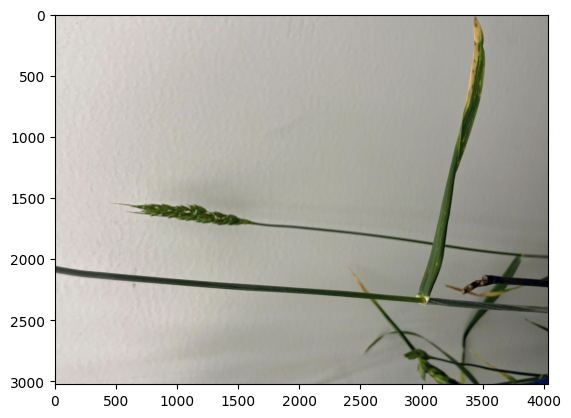

In [82]:
# check which leaf you are using
reference = io.imread('../../captured/Avocet+Yr15-control/')
plt.imshow(reference)

In [85]:
# remove yellow tone from images
processed_images = remove_yellow_tone(leaves, reference) # the reference is the first image in all the leaves

In [86]:
# save images
for i in range(len(files)):
    img_to_save = processed_images[i]
    path = directory+files[i] # same directory as before
    io.imsave(path, img_to_save, check_contrast=False)